## Parameter Sweeping

Will be conducted on
- PD.frame_size, PD.hop_size, PD.freq_range
- ND.frame_size, ND.hop_size, ND.slope, ND.diff
- SE.ins, SE.del, SE.sub

And we choose the combination of parameters which minimizes the edit distance.

### First, understanding...
It would be good to understand what general parameters are effective. What dictates the frame and hop for PD and ND? What about general slopes and diffs which work? When do they work vs fail?

In [43]:
# autoreload when modules edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import sys
sys.path.append('..')

from app_logic.midi.ScoreData import ScoreData
from app_logic.user.ds.Recording import Recording
from app_logic.user.ds.PitchData import PitchConfig
from app_logic.user.AudioRecorder import AudioRecorder
from app_logic.user.AudioPlayer import AudioPlayer

from algorithms.PitchDetector import PitchDetector
from algorithms.NoteDetector import NoteDetector
from algorithms.StringEditor import StringEditor
from algorithms.Config import Config

In [45]:
# initialize user data with sample recording
c = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 2,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.9, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 29, # frame size (NOTE: should always be odd)
    'h2': 19, # hop size
    'pitch_thresh': 0.75,
    # 'slope_thresh': 0.75 / 29,
    'unv_ratio': 0.8, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1,
    'min_close': 10
}
config = Config()
config.load_config(c)

sd = ScoreData(filepath='../resources/scores/fugue.mid')
rec = Recording(score_data=sd, config=config)
rec.load_audio('../resources/recordings/bach_fugue_recording.mp3') # also detects pitches and notes on load

Loading score file: ../resources/scores/fugue.mid
Handling MIDI file...


100%|██████████| 4498/4498 [00:02<00:00, 1680.21it/s]


### Test out multiple frame sizes (Pitch Detection)

In [5]:
c = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 2,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.9, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 29, # frame size (NOTE: should always be odd)
    'h2': 19, # hop size
    'pitch_thresh': 0.75,
    'slope_thresh': 0.75 / 29,
    'unv_ratio': 0.8, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config()
config.load_config(c)

frame_sizes = [1024 * 2, 1024 * 4, 1024 * 8]

for w1 in frame_sizes:
    print(f"result for w1 = {w1}")
    config.w1 = w1
    rec.update_config(config)
    rec.detect_pitches()
    rec.detect_notes()
    rec.detect_mistakes()
    print(rec.alignment)
    

result for w1 = 2048


  0%|          | 0/4498 [00:00<?, ?it/s]

100%|██████████| 4498/4498 [00:02<00:00, 1580.03it/s]


Starting string editing...
Done!
alignment (11 mistakes):
(0.38 | insertion) u: C#4, m: C#5
(0.75 | substitution) u: A5, m: F5
(1.88 | insertion) u: D5, m: F5
(3.00 | deletion) u: D5, m: D#5
(5.25 | insertion) u: D#5, m: F5
(7.50 | deletion) u: E4, m: E4
(8.63 | deletion) u: A4, m: A#4
(10.50 | deletion) u: A4, m: A#4
(11.06 | deletion) u: D5, m: F4
(11.63 | deletion) u: D5, m: G5
(12.00 | deletion) u: C5, m: F#5
result for w1 = 4096


100%|██████████| 4482/4482 [00:03<00:00, 1450.09it/s]


Starting string editing...
Done!
alignment (17 mistakes):
(0.75 | substitution) u: A5, m: F5
(0.94 | substitution) u: D4, m: A5
(1.88 | insertion) u: C#4, m: F5
(2.44 | substitution) u: F#5, m: F5
(2.63 | substitution) u: F5, m: D#5
(2.81 | substitution) u: D#5, m: D5
(3.94 | insertion) u: C4, m: G5
(6.56 | substitution) u: G#4, m: F#4
(6.94 | substitution) u: G4, m: A#4
(7.13 | substitution) u: A#4, m: D5
(7.50 | deletion) u: E4, m: E4
(8.63 | deletion) u: A4, m: A#4
(10.50 | deletion) u: A4, m: A#4
(10.88 | substitution) u: D#4, m: D5
(11.06 | deletion) u: D#4, m: F4
(11.63 | deletion) u: D#5, m: G5
(12.00 | substitution) u: C#5, m: F#5
result for w1 = 8192


100%|██████████| 4450/4450 [00:03<00:00, 1257.32it/s]


Starting string editing...
Done!
alignment (17 mistakes):
(0.75 | insertion) u: A5, m: F5
(1.69 | deletion) u: B4, m: D5
(3.00 | deletion) u: D5, m: D#5
(3.94 | substitution) u: C4, m: G5
(6.75 | deletion) u: G4, m: G4
(7.13 | deletion) u: A#4, m: D5
(7.50 | deletion) u: E4, m: E4
(7.69 | deletion) u: E4, m: G4
(8.63 | deletion) u: A4, m: A#4
(9.94 | substitution) u: C#5, m: C5
(10.13 | substitution) u: C5, m: A#4
(10.31 | substitution) u: A#4, m: A4
(10.88 | deletion) u: G4, m: D5
(11.06 | deletion) u: G4, m: F4
(11.44 | deletion) u: D#4, m: D5
(11.63 | deletion) u: D#4, m: G5
(12.00 | deletion) u: C5, m: F#5


### Test out multiple frame sizes (Note Detection)

In [46]:
c = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 2,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.9, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 29, # frame size (NOTE: should always be odd)
    'h2': 19, # hop size
    'pitch_thresh': 0.75,
    # 'slope_thresh': 0.75 / 29, # no longer needed to input manually
    'unv_ratio': 0.8, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1,
    'min_close': 10
}
config = Config()
config.load_config(c)
rec.update_config(config)
rec.detect_pitches() # just reset from the last time if needed

w2_sizes = [33, 31, 29, 27, 25, 23, 21, 19, 17]

best_w2, min_mistakes = 33, float('inf')
for w2 in w2_sizes:
    print(f"result for w2 = {w2}\n---")
    config.w2 = w2
    config.h2 = w2 - 2
    rec.update_config(config)
    # rec.detect_pitches()
    rec.detect_notes()
    rec.detect_mistakes()
    print(rec.alignment)

    n_mistakes = len(rec.alignment.mistakes)
    if n_mistakes < min_mistakes:
        best_w2, min_mistakes = w2, n_mistakes

print(f"best w2: {best_w2} with {min_mistakes} mistakes")
config.w2 = best_w2
config.h2 = best_w2 - 2
rec.update_config(config)
rec.detect_notes()
rec.detect_mistakes()

100%|██████████| 4498/4498 [00:02<00:00, 1640.50it/s]


result for w2 = 33
---
Starting string editing...
Done!
alignment (13 mistakes):
(0.75 | deletion) u: E5, m: F5
(1.13 | deletion) u: A5, m: D5
(1.69 | deletion) u: B4, m: D5
(3.00 | deletion) u: D5, m: D#5
(4.50 | deletion) u: A#4, m: A4
(5.06 | insertion) u: F5, m: G5
(7.50 | deletion) u: E4, m: E4
(7.69 | deletion) u: E4, m: G4
(8.63 | deletion) u: A4, m: A#4
(10.50 | deletion) u: A4, m: A#4
(11.06 | deletion) u: D5, m: F4
(11.63 | deletion) u: D5, m: G5
(12.00 | deletion) u: C5, m: F#5
result for w2 = 31
---
Starting string editing...
Done!
alignment (11 mistakes):
(0.75 | deletion) u: E5, m: F5
(1.13 | deletion) u: A5, m: D5
(1.88 | insertion) u: D5, m: F5
(3.00 | deletion) u: D5, m: D#5
(7.50 | deletion) u: E4, m: E4
(8.63 | deletion) u: A4, m: A#4
(10.31 | deletion) u: A#4, m: A4
(10.50 | deletion) u: A#4, m: A#4
(11.06 | deletion) u: D5, m: F4
(11.63 | substitution) u: D5, m: G5
(12.00 | deletion) u: C5, m: F#5
result for w2 = 29
---
Starting string editing...
Done!
alignment (1

## Post-editing

Deletion checking - if correct pitch present in user note prev or next, erase the deletion

In [ ]:
import numpy as np
from app_logic.NoteData import Note
from app_logic.user.ds.PitchData import Pitch

def _find_split(pitches: list[Pitch], midi_1: float, midi_2: float):
    """Find the best single breakpoint for a given sequence of pitches.
    Assumes it should split into two distinct notes from the MIDI score (midi_1, midi_2).

    Args:
        pitches (list[Pitch]): List of pitch objects.
        midi_1 (float): MIDI number of the first note.
        midi_2 (float): MIDI number of the second note.

    Returns:
        int: Index into the list of pitches where the second note starts.
    """"
    midi_nums = np.array([p.candidates[0][0] for p in pitches])
    d1 = np.abs(midi_nums - midi_1)
    d2 = np.abs(midi_nums - midi_2)
    pre1 = np.concatenate([[0.0], np.cumsum(d1)])             # pre1[k] = sum(d1[:k])
    suf2 = np.concatenate([np.cumsum(d2[::-1])[::-1], [0.0]]) # suf2[k] = sum(d2[k:])
    cost = pre1 + suf2
    return int(np.argmin(cost[1:-1]) + 1)                    # +1 keeps both segments non-empty

def split_user_note(note, pitches, midi_1, midi_2):
    """Split one user Note into two at the optimal pitch boundary. Returns (first, second) or None."""
    voiced = [p for p in pitches if p is not None and p.candidates[0][0] != -1]
    if len(voiced) < 2:
        return None
    k = _find_split(voiced, midi_1, midi_2)
    split_time = voiced[k].time

    # use the measured median of each side as the note's pitch (honest to what was played)
    left  = np.median([p.candidates[0][0] for p in voiced[:k]])
    right = np.median([p.candidates[0][0] for p in voiced[k:]])

    first  = Note(
        i=note.id, 
        start_time=note.start_time, 
        end_time=split_time,
        midi_num=[float(left)],
        instrument=note.instrument
    )
    second = Note(
        i=note.id, 
        start_time=split_time,
        end_time=note.end_time,
        midi_num=[float(right)], 
        instrument=note.instrument
    )
    return first, second

In [ ]:
for mistake in rec.alignment.mistakes:
    print(mistake)
    if mistake.type == "deletion":
        intended_note = mistake.midi_note
        prev_note = mistake.user_note
        next_note = rec.note_data.read_note(i=prev_note.id + 1)
        print(f"   > prev_note (i={prev_note.id}): {prev_note.get_note_name()} at {prev_note.start_time:.2f}s")
        print(f"   > next_note (i={next_note.id}): {next_note.get_note_name()} at {next_note.start_time:.2f}s")

        # --- look at pitches in prev / next note and see if we could split either to recover the intended note ---
        prev_pitches = rec.pitch_data.read(start_time=prev_note.start_time, end_time=prev_note.end_time, clean=True)
        next_pitches = rec.pitch_data.read(start_time=next_note.start_time, end_time=next_note.end_time, clean=True)

        print(f" --- INTENDED NOTE: {intended_note.get_note_name()} --- ")
        n_close_prev = sum(1 for p in prev_pitches if abs(p.candidates[0][0] - intended_note.midi_num[0]) <= config.tolerance)
        n_close_next = sum(1 for p in next_pitches if abs(p.candidates[0][0] - intended_note.midi_num[0]) <= config.tolerance)
        print(f"   > {n_close_prev} close pitches in prev note, {n_close_next} close pitches in next note")
        MIN_CLOSE = 10
        target = intended_note.midi_num[0]
        if max(n_close_prev, n_close_next) >= MIN_CLOSE:
            if n_close_prev >= n_close_next:
                # intended note was merged into the END of prev_note
                host, host_pitches = prev_note, prev_pitches
                midi_1, midi_2  = host.midi_num[0], target
            else:
                # intended note was merged into the START of next_note
                host, host_pitches = next_note, next_pitches
                midi_1, midi_2  = target, host.midi_num[0]

            result = split_user_note(host, host_pitches, midi_1, midi_2)
            if not result:
                print("   > host note had too few voiced frames to split")
                continue
            note_type = "prev" if host == prev_note else "next"
            first, second = result
            print(f"   > SPLIT {note_type} note i={host.id} ({host.get_note_name()}) into:")
            print(f"       {first.get_note_name()}  [{first.start_time:.2f}–{first.end_time:.2f}s]")
            print(f"       {second.get_note_name()} [{second.start_time:.2f}–{second.end_time:.2f}s]")
        else:
            print(f"   > not enough close pitches ({n_close_prev}/{n_close_next} < {MIN_CLOSE}) — no split")

(0.65 | substitution) u: G4, m: E5
(3.00 | deletion) u: -, m: D#5
   > prev_note (i=17): D5 at 3.12s
   > next_note (i=18): G4 at 3.48s
 --- INTENDED NOTE: D#5 --- 
   > 125 close pitches in prev note, 4 close pitches in next note
   > SPLIT prev note i=17 (D5) into:
       D5  [3.12–3.33s]
       D#5 [3.33–3.48s]
(3.75 | deletion) u: -, m: D#5
   > prev_note (i=20): D#5 at 4.06s
   > next_note (i=21): G5 at 4.28s
 --- INTENDED NOTE: D#5 --- 
   > 74 close pitches in prev note, 0 close pitches in next note
   > SPLIT prev note i=20 (D#5) into:
       D#5  [4.06–4.22s]
       D#5 [4.22–4.28s]
(7.50 | deletion) u: -, m: E4
   > prev_note (i=41): E4 at 7.91s
   > next_note (i=42): B-2 at 8.20s
 --- INTENDED NOTE: E4 --- 
   > 98 close pitches in prev note, 0 close pitches in next note
   > SPLIT prev note i=41 (E4) into:
       E4  [7.91–8.02s]
       E4 [8.02–8.20s]
(8.63 | deletion) u: -, m: A#4
   > prev_note (i=47): A4 at 9.00s
   > next_note (i=48): G4 at 9.29s
 --- INTENDED NOTE: A#

### Driver: `MistakeChecker` before / after

Runs the packaged `MistakeChecker` over the current `rec` and compares the
alignment before/after splitting merged notes (then re-running string editing).

In [47]:
from collections import Counter
from algorithms.MistakeChecker import MistakeChecker

print(f"BEFORE: {len(rec.alignment.mistakes)} mistakes, {len(rec.note_data.times)} notes")
print(rec.alignment)

checker = MistakeChecker(recording=rec)
new_nd, new_alignment = checker.check_mistakes()

print(f"\nAFTER:  {len(new_alignment.mistakes)} mistakes, {len(new_nd.times)} notes")
print(new_alignment)

# breakdown of what changed, by mistake type
before = Counter(m.type for m in rec.alignment.mistakes)
after  = Counter(m.type for m in new_alignment.mistakes)
print("\n--- by type (before -> after) ---")
for t in ("deletion", "substitution", "insertion"):
    print(f"  {t:13s}: {before.get(t, 0)} -> {after.get(t, 0)}")
print(f"  {'notes':13s}: {len(rec.note_data.times)} -> {len(new_nd.times)}")

BEFORE: 9 mistakes, 68 notes
alignment (9 mistakes):
(0.56 | substitution) u: G4, m: E5
(3.00 | deletion) u: D5, m: D#5
(3.75 | deletion) u: D#5, m: D#5
(7.50 | deletion) u: E4, m: E4
(8.63 | deletion) u: A4, m: A#4
(10.50 | deletion) u: A4, m: A#4
(11.06 | deletion) u: D5, m: F4
(11.63 | substitution) u: D5, m: G5
(12.00 | deletion) u: C5, m: F#5
Starting string editing...
Done!

AFTER:  4 mistakes, 73 notes
alignment (4 mistakes):
(0.56 | substitution) u: G4, m: E5
(11.06 | deletion) u: D5, m: F4
(11.63 | substitution) u: D5, m: G5
(12.00 | deletion) u: C5, m: F#5

--- by type (before -> after) ---
  deletion     : 7 -> 2
  substitution : 2 -> 2
  insertion    : 0 -> 0
  notes        : 68 -> 73


### Accuracy check: Pitch Detection

Compare the detected pitches of audio to the MIDI file it was originally synthesized from.

In [70]:
# test pitch detection accuracy
import pretty_midi
import soundfile as sf

SF_PATH = "../resources/MuseScore_General.sf3"
INPUT_MIDI_PATH = "../resources/scores/fugue.mid"
OUTPUT_PATH = "../resources/scores/midi-to-audio/fugue.wav"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 8,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 30, # frame size
    'h2': 27, # hop size
    'pitch_thresh': 0.75,
    'slope_thresh': 1.5,
    'unv_ratio': 0.5, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# synthesize midi to audio
mid = pretty_midi.PrettyMIDI(INPUT_MIDI_PATH)
audio = mid.fluidsynth(synthesizer=SF_PATH, fs=44100)
sf.write(OUTPUT_PATH, audio, 44100)

# load and detect pitches
pd, nd = PitchDetector(config), NoteDetector(config)
us1 = UserData(pd, nd)
us1.load_audio(OUTPUT_PATH)

Starting pitch detection...
Processing frame 4544/4544
Done!
Starting note detection...
Note detection: Done!


In [3]:
# test pitch detection accuracy
ANNOT_DIR = "../resources/mdb-stem-synth/annotation_stems/AClassicEducation_NightOwl_STEM_01.RESYN.csv"
AUDIO_DIR = "../resources/mdb-stem-synth/audio_stems/AClassicEducation_NightOwl_STEM_01.RESYN.wav"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 8,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 30, # frame size
    'h2': 27, # hop size
    'pitch_thresh': 0.75,
    'slope_thresh': 1.5,
    'unv_ratio': 0.5, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# load and detect pitches
pd, nd = PitchDetector(config), NoteDetector(config)
us1 = UserData(pd, nd)
us1.load_audio(AUDIO_DIR)

Starting pitch detection...
Processing frame 59003/59003
Done!
Starting note detection...
Note detection: Done!


In [65]:
import pandas as pd

rows = []
mid1 = MidiData(INPUT_MIDI_PATH)

for p in us1.pitch_data.data:
    t = p.time
    if p.unvoiced_prob > config.unv_thresh:
        continue # skip unvoiced frames
    
    p_u = p.candidates[0][0] # most probable candidate
    
    midi_note = mid1.note_data.read_note(start_time=t)
    p_m = midi_note.midi_num[0]

    err = abs(p_u - p_m)
    correct = err <= 0.5

    rows.append({
        "time": t,
        "detected_pitch": p_u,
        "true_pitch": p_m,
        "error": err,
        "correct": correct,
    })

# aggregate statistics
df = pd.DataFrame(rows)

total_pitches   = len(df)
correct_pitches = df["correct"].sum()
median_error      = df["error"].median()
accuracy        = correct_pitches / total_pitches * 100

print(f"Total pitches: {total_pitches}")
print(f"Correct pitches: {correct_pitches}")
print(f"Median Error: {median_error}")
print(f"Accuracy: {accuracy}%")


Loading score file: ../resources/scores/fugue.mid (ext: .mid)
Handling MIDI file...
Total pitches: 3442
Correct pitches: 2426
Median Error: 0.06945197345606147
Accuracy: 70.4822777454968%


### Pitch Detection: Plots
Accuracy, errors, etc.

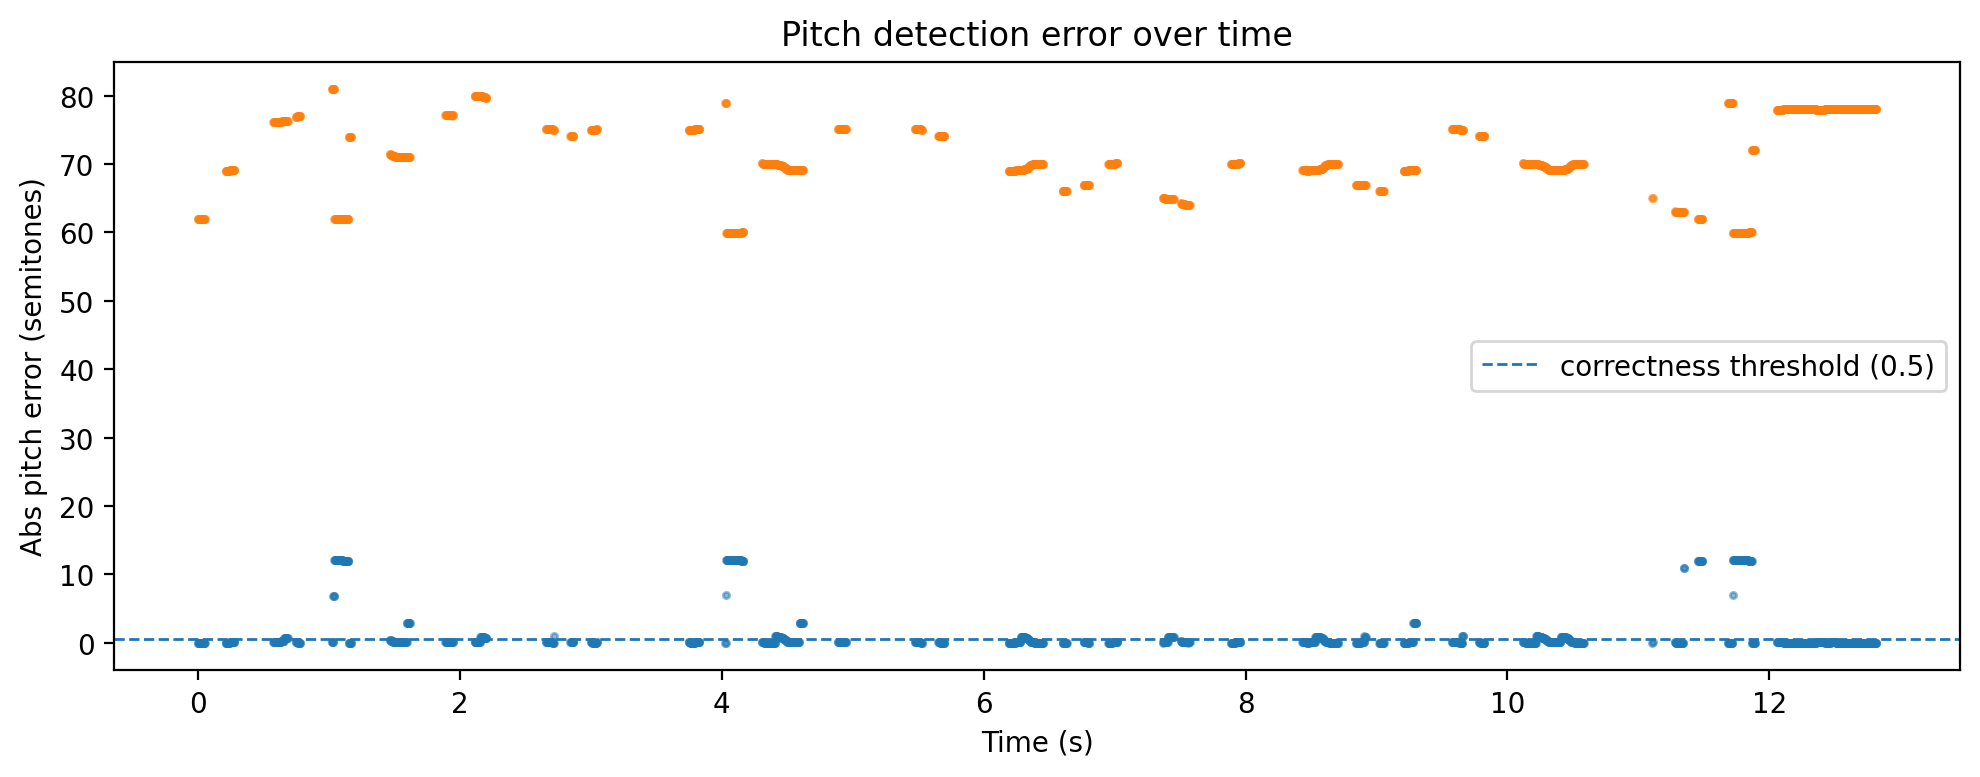

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# scatter of absolute error over time
plt.scatter(df["time"], df["error"], s=5, alpha=0.5)
plt.scatter(df["time"], df["detected_pitch"], s=5, alpha=0.5)
plt.axhline(0.5, linestyle="--", linewidth=1, label="correctness threshold (0.5)")
plt.xlabel("Time (s)")
plt.ylabel("Abs pitch error (semitones)")
plt.title("Pitch detection error over time")
plt.legend()
plt.tight_layout()
plt.show()

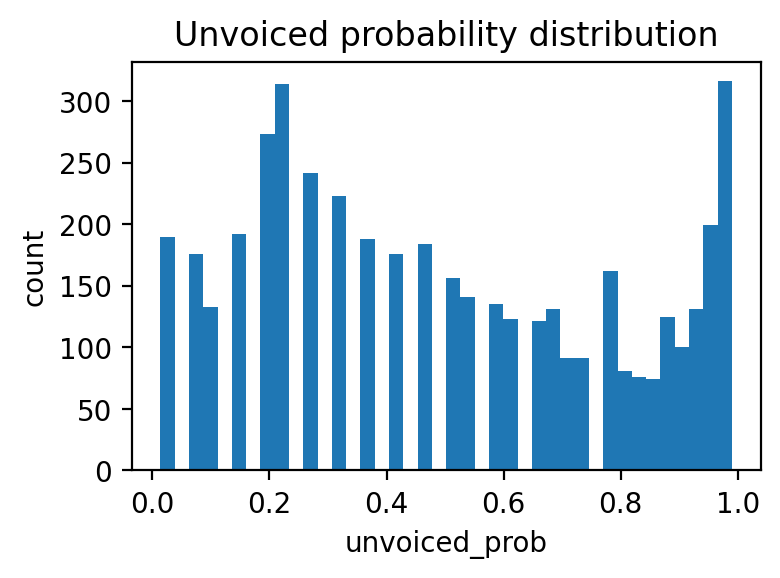

In [57]:
unvoiced_probs = [p.unvoiced_prob for p in us1.pitch_data.data]

plt.figure(figsize=(4, 3))
plt.hist(unvoiced_probs, bins=40)
plt.xlabel("unvoiced_prob")
plt.ylabel("count")
plt.title("Unvoiced probability distribution")
plt.tight_layout()
plt.show()

In [21]:
from IPython.display import Audio

Audio(data=us1.audio_data.data, rate=us1.audio_data.sr)

In [66]:
%gui qt

import sys
from PyQt6.QtWidgets import QApplication
from PyQt6.QtCore import QCoreApplication

sys.path.append('../')
from ui.ScorePlot import RunScorePlot

if __name__ == '__main__':
    if not QCoreApplication.instance():
        app = QApplication(sys.argv)
    else:
        app = QCoreApplication.instance()

    vis = RunScorePlot(user_data=us1, midi_data=mid1, app=app)

Loading MIDI data into ScorePlot...
Loading UserData into ScorePlot...


In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    # --- PITCH DETECTION PARAMETERS ---
    w1: int = 1024 * 6  # frame size
    h1: int = 128       # hop size
    fmin: float = 196.0
    fmax: float = 5000.0
    tuning: float = 440.0
    unv_thresh: float = 0.3

    # --- NOTE DETECTION PARAMETERS ---
    w2: int = 30 # frame size
    h2: int = 27 # hop size
    pitch_thresh: float = 0.5
    slope_thresh: float = 1.5

    # --- STRING EDIT PARAMETERS ---
    ins_cost: float = 1.5
    del_cost: float = 2
    sub_cost: float = 1
    tolerance: float = 1                                              

    # tiger-mom parameter
    tiger_level: int = 1
